Worksheet 4 : Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification.

In [1]:
pip install keras tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
print(tf.keras.__version__)

3.9.0


1. Load and Preprocess the Data:

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


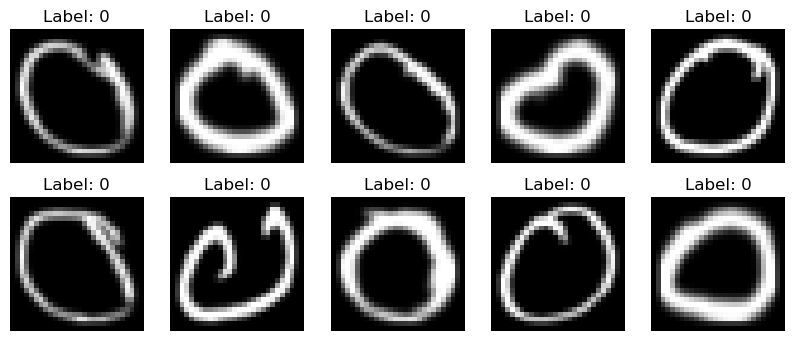

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

# Define dataset paths
train_dir = "DevanagariHandwrittenDigitDataset/Train"
test_dir = "DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels
    
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28, 28)
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)
    
    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)  # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)
# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 18s 2us/step


2. Build the Model:

In [9]:
# Reshape dataset to add the channel dimension (28, 28) → (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Check new shape
print(f"New x_train shape: {x_train.shape}")
print(f"New x_test shape: {x_test.shape}")


New x_train shape: (60000, 28, 28, 1)
New x_test shape: (10000, 28, 28, 1)


In [10]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

3. Compile The Model 

In [11]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


4. Train the Model 

In [12]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2  # 20% for validation
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4828 - loss: 1.6153 - val_accuracy: 0.8991 - val_loss: 0.3697
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9020 - loss: 0.3474 - val_accuracy: 0.9268 - val_loss: 0.2491
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9306 - loss: 0.2327 - val_accuracy: 0.9385 - val_loss: 0.2112
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9472 - loss: 0.1799 - val_accuracy: 0.9511 - val_loss: 0.1686
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9546 - loss: 0.1548 - val_accuracy: 0.9588 - val_loss: 0.1445
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9631 - loss: 0.1273 - val_accuracy: 0.9599 - val_loss: 0.1389
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9672 - loss: 0.1109 - val_accuracy: 0.9608 - val_loss: 0.1325
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9724 - loss: 0.0976 - val_accuracy: 0.

5. Evaluate the Model on Test Data

In [13]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.9662 - loss: 0.1347
Test Accuracy: 96.99%


6. Save Load the Model 

In [14]:
model.save("devnagari_model.h5")
print("Model saved successfully!")


Model saved successfully!


In [15]:
from tensorflow.keras.models import load_model

loaded_model = load_model("devnagari_model.h5")
print("Model loaded successfully!")


Model loaded successfully!


7. Make Predictions

In [16]:
predictions = model.predict(x_test[:5])  # Predict first 5 images
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted Labels:", predicted_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Labels: [7 2 1 0 4]


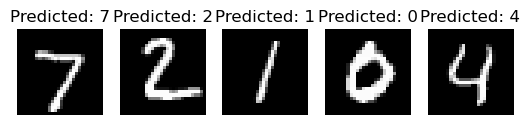

In [18]:
import matplotlib.pyplot as plt

# Plot the first 5 test images with their predicted labels
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")  # Show the image
    plt.title(f"Predicted: {predicted_labels[i]}")  # Show the model's guess
    plt.axis("off")

plt.show()


8. Plot Training Accuracy & Loss

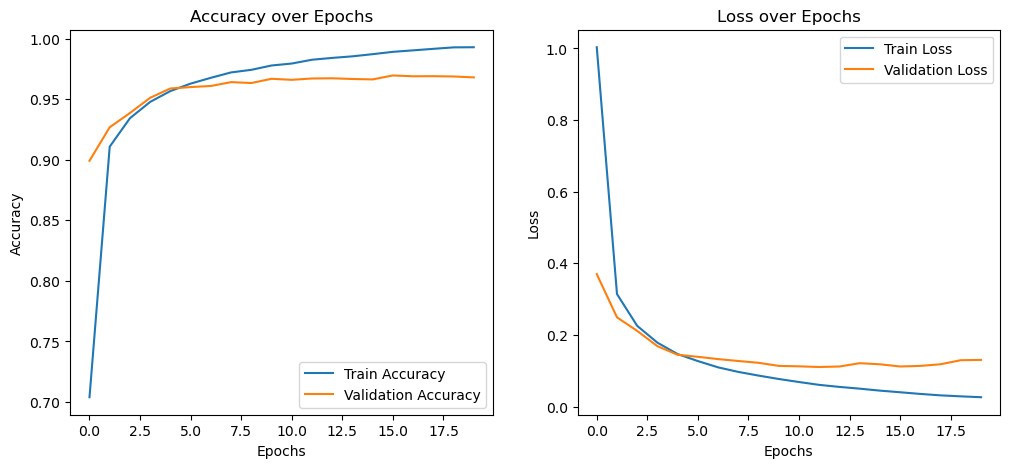

In [17]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.show()


#6. Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

In [20]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image
from sklearn.model_selection import train_test_split

# Define dataset paths
train_dir = "DevanagariHandwrittenDigitDataset/Train"
test_dir = "DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels
def load_images_labels(data_dir):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))  # Get class names from folder names
    
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue  # Skip files, only process directories
        
        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_height, img_width))  # Resize to 28x28
            images.append(np.array(img))
            labels.append(label)
    
    return np.array(images), np.array(labels)

# Load training and testing data
x_train, y_train = load_images_labels(train_dir)
x_test, y_test = load_images_labels(test_dir)

# Normalize images (scale pixel values between 0 and 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape to fit Keras input shape (samples, 28, 28, 1)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print("Training data shape:", x_train.shape, y_train.shape)
print("Testing data shape:", x_test.shape, y_test.shape)


Training data shape: (17000, 28, 28, 1) (17000, 10)
Testing data shape: (3000, 28, 28, 1) (3000, 10)


2. Building FCN and 3. Compile the model 

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Define the Fully Connected Neural Network with the correct architecture
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # Flatten the image (28x28) to a 1D vector
    Dense(64, activation='sigmoid'),   # 1st hidden layer (64 neurons)
    Dense(128, activation='sigmoid'),  # 2nd hidden layer (128 neurons)
    Dense(256, activation='sigmoid'),  # 3rd hidden layer (256 neurons)
    Dense(10, activation='softmax')    # Output layer (10 neurons for 10 classes)
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

4. Train the FCN Model

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    x_train, y_train,
    batch_size=128,         # Batch size set to 128
    epochs=20,              # Train for 20 epochs
    validation_split=0.2,   # 20% of training data used for validation
    callbacks=[checkpoint, early_stopping]  # Use callbacks to save best model and stop early
)


Epoch 1/20
 92/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9997 - loss: 0.0011     
Epoch 1: val_loss improved from inf to 0.00209, saving model to best_model.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9998 - loss: 0.0010 - val_accuracy: 0.9997 - val_loss: 0.0021
Epoch 2/20
 92/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 5.0169e-04
Epoch 2: val_loss did not improve from 0.00209
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 5.0335e-04 - val_accuracy: 0.9991 - val_loss: 0.0029
Epoch 3/20
 93/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 4.4607e-04
Epoch 3: val_loss did not improve from 0.00209
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 4.4884e-04 - val_accuracy: 0.9991 - val_loss: 0.0031
Epoch 4/20
 88/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 4.5865e-04 
Epoch 4: val_loss did not improve from 0.00209
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 4.5122e-04 - val_accuracy: 0.9991 - val_loss: 0.0035
Epoch 5/20
 91/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 3.5400e-04
Epoch 5: val_loss 

5. Evaluate the Model

In [35]:
# Evaluate the trained model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Print test results
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.9865 - loss: 0.0695   
Test Accuracy: 98.33%
Test Loss: 0.0832


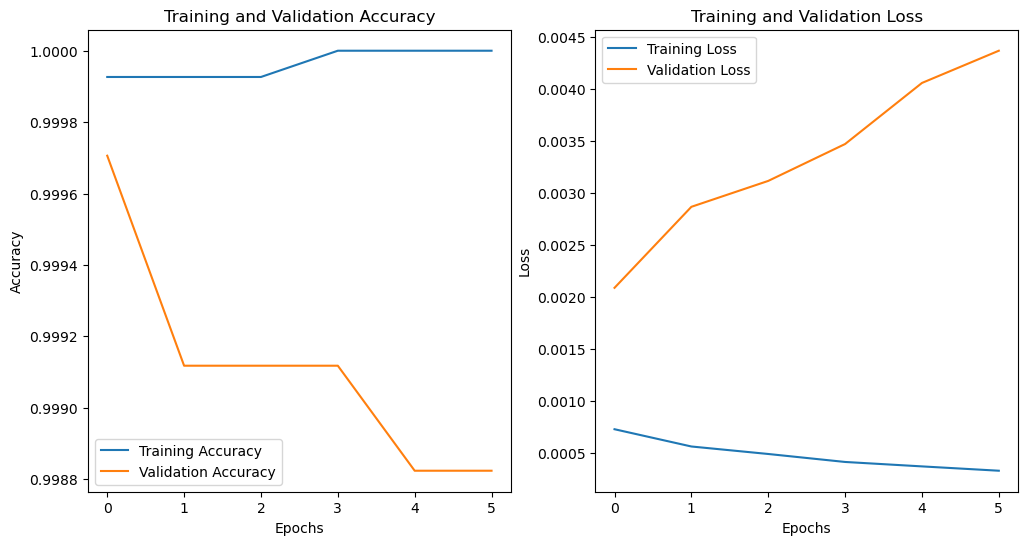

In [36]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


6. Save and Load the model 

In [28]:
# Save the trained model to an HDF5 (.h5) file
model.save("handwritten_digit_model.h5")

print("Model saved successfully!")


Model saved successfully!


In [29]:
# Load the saved model
from tensorflow.keras.models import load_model

loaded_model = load_model("handwritten_digit_model.h5")

# Evaluate the loaded model on the test set
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test)

# Print test results for the loaded model
print(f"Loaded Model Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Loaded Model Test Loss: {test_loss:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.9865 - loss: 0.0695    
Loaded Model Test Accuracy: 98.33%
Loaded Model Test Loss: 0.0832


7. Make Predictions 

In [30]:
# Make predictions on the test set
predictions = model.predict(x_test)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Convert one-hot encoded test labels back to original digit labels
true_labels = np.argmax(y_test, axis=1)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step


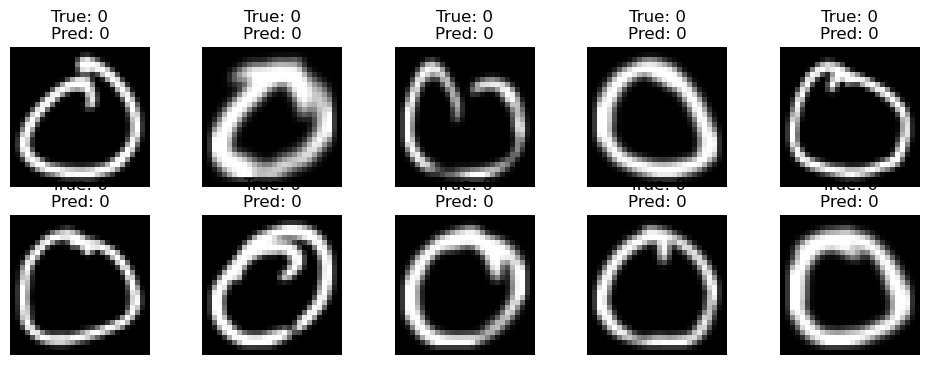

In [31]:
import matplotlib.pyplot as plt

# Function to visualize predictions
def plot_sample_predictions(x_test, true_labels, predicted_labels, num_samples=10):
    plt.figure(figsize=(12, 4))
    for i in range(num_samples):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap="gray")  # Display image
        plt.axis("off")
        plt.title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
    plt.show()

# Display 10 sample predictions
plot_sample_predictions(x_test, true_labels, predicted_labels)
